In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import math

from svi import SVI, SVIParams
import option_chain_generator as oc

## Abstract

**The goal of this notebook is to build a prototype of a Dupire workflow.**
- From an option chain (in this case, synthetic data - see option_chain_generator.py for full code & documentation), fit an SVI total implied variance curve for each maturity.
- From there, interpolate between each maturity to obtain a volatilty implied surface
- Derive the Dupire local vol from this volatility surface

**Limitations:**
- Reliance on synthetic data does not capture real market features 
- Short maturities are excluded to keep the local volatility stable
- Choice of a relatively low number of options to keep interpolation smooth

## Option Data Generation

In [3]:
mat_dates = (30, 60, 90, 180, 270, 360)

In [4]:
data = oc.make_synth_iv_chain_svi(maturities_days=mat_dates)
data["log_moneyness"] = np.log(data["K"] / data["F"]) #log moneyness
data["w"] = data["iv_mid"]**2 * data['T'] #total variance

df = data.copy()

In [5]:
df.head()

,T,T_days,K,OptionType,iv_mid,iv_bid,iv_ask,F,S0,r,q,log_moneyness,w
0,0.082192,30,74.203701,C,0.584081,0.581081,0.587081,100.164519,100.0,0.02,0.0,-0.30,0.028040
1,0.082192,30,74.203701,P,0.584081,0.581081,0.587081,100.164519,100.0,0.02,0.0,-0.30,0.028040
2,0.082192,30,75.702715,C,0.568133,0.565133,0.571133,100.164519,100.0,0.02,0.0,-0.28,0.026529
3,0.082192,30,75.702715,P,0.568133,0.565133,0.571133,100.164519,100.0,0.02,0.0,-0.28,0.026529
4,0.082192,30,77.232011,C,0.555238,0.552238,0.558238,100.164519,100.0,0.02,0.0,-0.26,0.025339


## Smile visualisation

In [6]:
plt.style.use('dark_background')

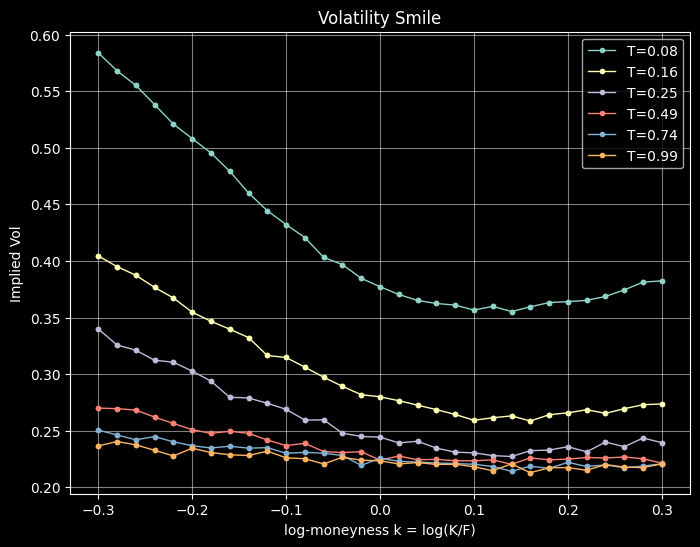

In [7]:
%matplotlib inline
T_unique = np.sort(df["T"].unique())
plt.figure(figsize=(8,6))

for T0 in T_unique:
    d = df[df["T"] == T0].copy()
    plt.plot(d["log_moneyness"], d["iv_mid"], marker="o", ms=3, lw= 1, label=f"T={T0:.2f}")

plt.xlabel("log-moneyness k = log(K/F)")
plt.ylabel("Implied Vol")
plt.title("Volatility Smile")
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()


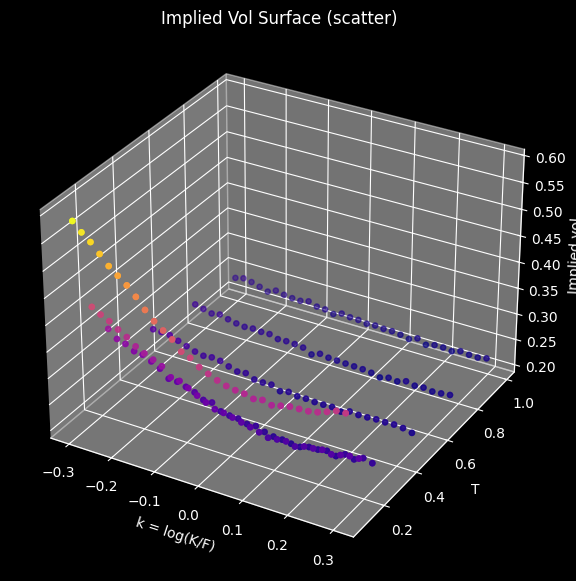

In [8]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["log_moneyness"], df["T"], df["iv_mid"],
    s=14,
    c=df["iv_mid"],
    cmap="plasma"
)

ax.set_xlabel("k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Implied vol")
ax.set_title("Implied Vol Surface (scatter)")

plt.show()


In [9]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=df["log_moneyness"],
            y=df["T"],
            z=df["iv_mid"],
            mode="markers",
            marker=dict(
                size=4,
                color=df["w"],
                colorscale="Plasma",
                opacity=1)
                )
                ]
)

fig.update_layout(
    title="Implied Vol Surface (scatter)",
    scene=dict(
        xaxis_title="k = log(K/F)",
        yaxis_title="T",
        zaxis_title="Implied vol",
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1)),
    width=700,
    height=700
)
fig.update_layout(template="plotly_dark")
fig.show()



In [10]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=df["log_moneyness"],
            y=df["T"],
            z=df["iv_mid"],
            mode="markers",
            marker=dict(
                size=4,
                color=df["w"],
                colorscale="Plasma",
                opacity=0.85)
                )
                ]
)

fig.update_layout(
    title="Implied Vol Surface (scatter)",
    scene=dict(
        xaxis_title="k = log(K/F)",
        yaxis_title="T",
        zaxis_title="Implied vol"
    ),
    width=900,
    height=700,
)
fig.update_layout(template="plotly_dark")
fig.show()

# SVI Fit

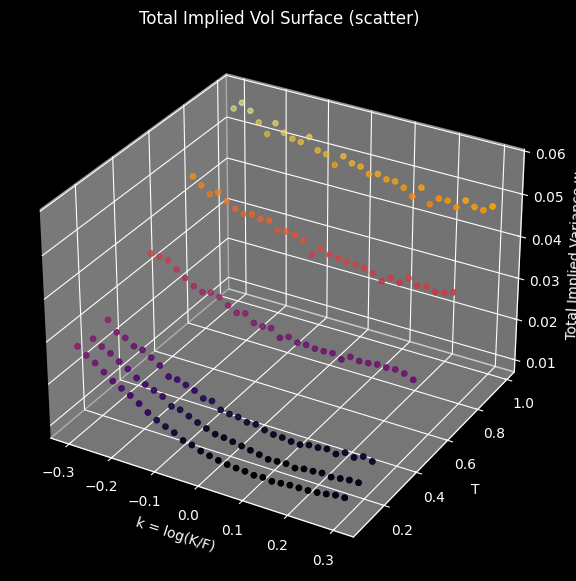

In [11]:

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(df["log_moneyness"], df["T"], df["w"], s=14, c=df["w"], cmap = 'inferno')

ax.set_xlabel("k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Total Implied Variance w")

ax.set_title("Total Implied Vol Surface (scatter)")
plt.show()

In [12]:
df = data[data["OptionType"]== "C"]


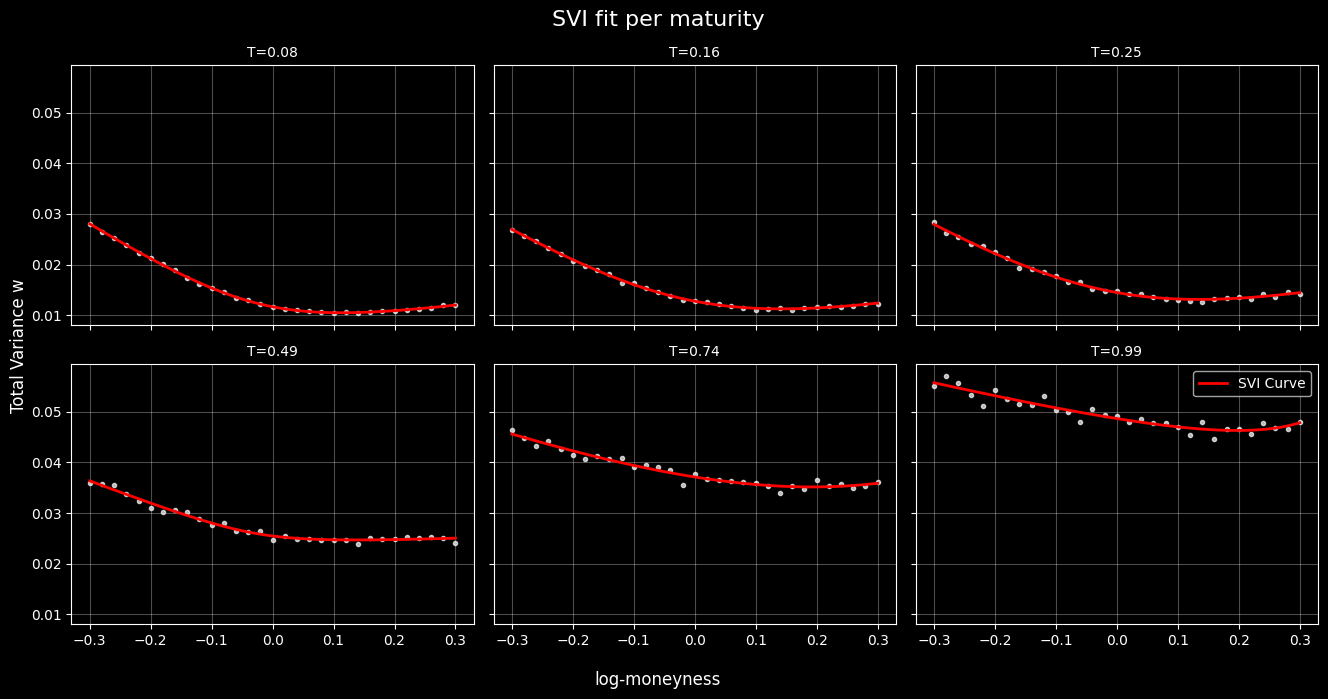

In [13]:
svi = SVI()

n = len(T_unique[:12])
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 3.5*n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(T_unique[:12]):
    ax = axes[i]
    sub = df[df["T"] == t]

    params = svi.fit(sub["log_moneyness"], sub["w"])
    lm = np.linspace(sub["log_moneyness"].min(), sub["log_moneyness"].max(), 200)

    w_fit = svi.compute(lm, params)
    iv_fit = np.sqrt(np.maximum(w_fit, 0.0) / t)

    ax.plot(sub["log_moneyness"], sub["w"], "o", markersize=3, alpha=0.7, color = "white")
    ax.plot(lm, w_fit, "-", linewidth=2, color = "red", label = "SVI Curve")


    ax.set_title(f"T={t:.2f}", fontsize=10)
    ax.grid(True, alpha=0.3)
    

for j in range(i+1, len(axes)):
    axes[j].axis("off")

ax.legend()
fig.supxlabel("log-moneyness")
fig.supylabel("Total Variance w")
fig.suptitle("SVI fit per maturity", fontsize=16)
plt.tight_layout()
plt.show()



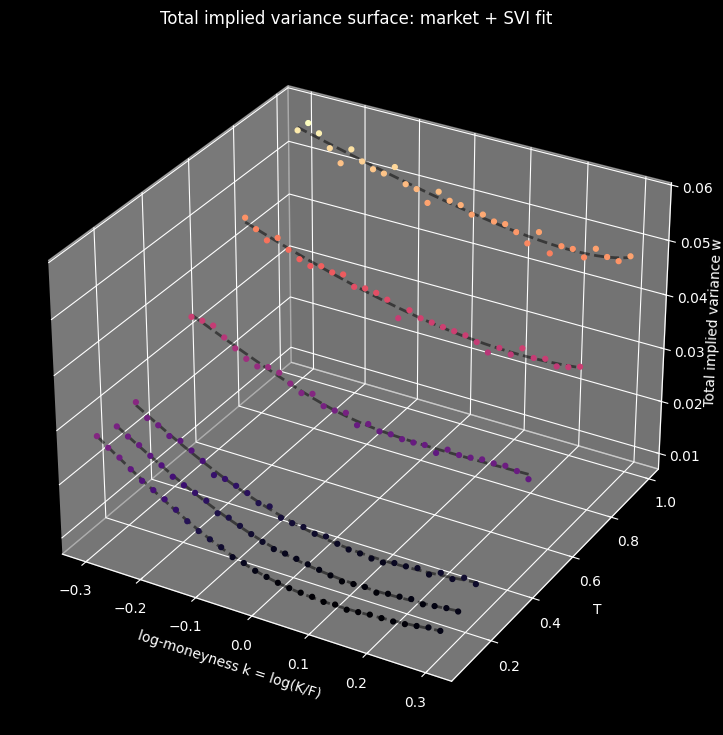

In [14]:

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    df["log_moneyness"],
    df["T"],
    df["w"],
    s=12,
    alpha=1,
    c=df["w"],
    cmap="magma"
)
svi = SVI()
params_by_T = {}
w_fit_by_t = {}

for t in T_unique:
    sub = df[df["T"] == t]
    params = svi.fit(
        sub["log_moneyness"].to_numpy(),
        sub["w"].to_numpy()
    )
    lm_grid = np.linspace(
        sub["log_moneyness"].min(),
        sub["log_moneyness"].max(),
        200
    )
    w_fit = svi.compute(lm_grid, params) 
    ax.plot(
        lm_grid,
        np.full_like(lm_grid, t),
        w_fit,
        linewidth=2, 
        linestyle = "--",
        color = "black",
        alpha = 0.5
    )

    w_fit_by_t[t] = (lm_grid, w_fit)
    params_by_T[t] = params

ax.set_xlabel("log-moneyness k = log(K/F)")
ax.set_ylabel("T")
ax.set_zlabel("Total implied variance w", labelpad=1)
ax.set_title("Total implied variance surface: market + SVI fit")


plt.show()



In [15]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=df["log_moneyness"],
        y=df["T"],
        z=df["w"],
        mode="markers",
        name="Market",
        marker=dict(
            size=4,
            color=df["w"],
            colorscale="Plasma",
            colorbar=dict(title="Total variance w")))
            
            )

for T, (lm_grid, w_fit) in w_fit_by_t.items():
    fig.add_trace(
        go.Scatter3d(
            x=lm_grid,
            y=np.full_like(lm_grid, T),
            z=w_fit,
            mode="lines",
            name=f"SVI fit T={T:.2f}",
            line=dict(
                color="rgba(255,255,255,0.55)",
                width=4,
                dash="dash"
            ),
            showlegend=False))
fig.update_layout(
    template="plotly_dark",
    title="Total implied variance surface: market points + SVI fits",
    width=800,
    height=800,
    scene=dict(
        xaxis_title="log-moneyness k = log(K/F)",
        yaxis_title="T",
        zaxis_title="Total implied variance w",
        xaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)"),
        yaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)"),
        zaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)"),
    ),
    margin=dict(l=0, r=0, t=60, b=0),
)
fig.write_html("interactive_plots/svi_fit.html")
fig.show()


## Volatility Surface

### Interpolation

In [52]:
from scipy.interpolate import PchipInterpolator

T_grid = np.array(sorted(params_by_T.keys()), dtype=float)
log_moneyness_grid = np.linspace(df["log_moneyness"].min(), df["log_moneyness"].max(), 20)

W = np.vstack([svi.compute(log_moneyness_grid, params_by_T[T]) for T in T_grid])  
interp_T = [PchipInterpolator(T_grid, W[:, j], extrapolate=False) for j in range(W.shape[1])]

def w_interp(log_moneyness, T):
    """Interpolate total variance w(log_moneyness, T) from fitted SVI smiles"""
    log_moneyness = float(log_moneyness); T = float(T)
    w_on_log_moneyness_grid = np.array([f(T) for f in interp_T])

    return np.interp(log_moneyness, log_moneyness_grid, w_on_log_moneyness_grid)


In [63]:
T_grid_dense = np.linspace(T_grid.min(), T_grid.max(), 60)

W_surface = np.zeros((len(T_grid_dense), len(log_moneyness_grid)))

for i, T in enumerate(T_grid_dense):
    for j, lm in enumerate(log_moneyness_grid):
        W_surface[i, j] = w_interp(lm, T)
W_surface = np.maximum.accumulate(W_surface, axis=0) ## to guarantee no arbitrage

In [64]:
IV_surface = np.sqrt(np.maximum(W_surface, 0.0) / T_grid_dense[:, None])

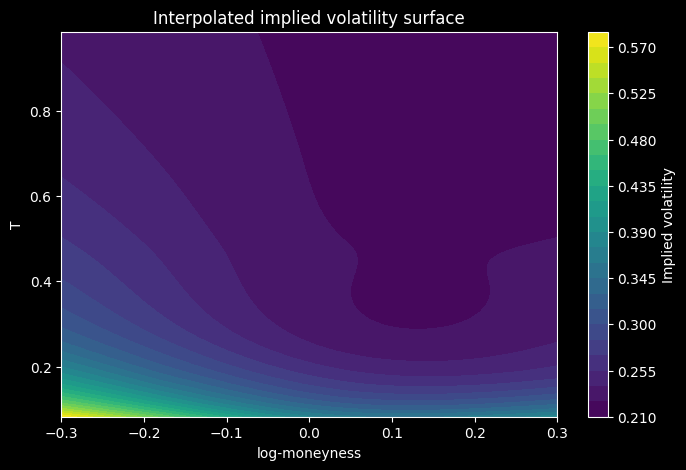

In [65]:
LM, TT = np.meshgrid(log_moneyness_grid, T_grid_dense)

plt.figure(figsize=(8, 5))
plt.contourf(LM, TT, IV_surface, levels=30, cmap="viridis")
plt.colorbar(label="Implied volatility")
plt.xlabel("log-moneyness")
plt.ylabel("T")
plt.title("Interpolated implied volatility surface")
plt.show()


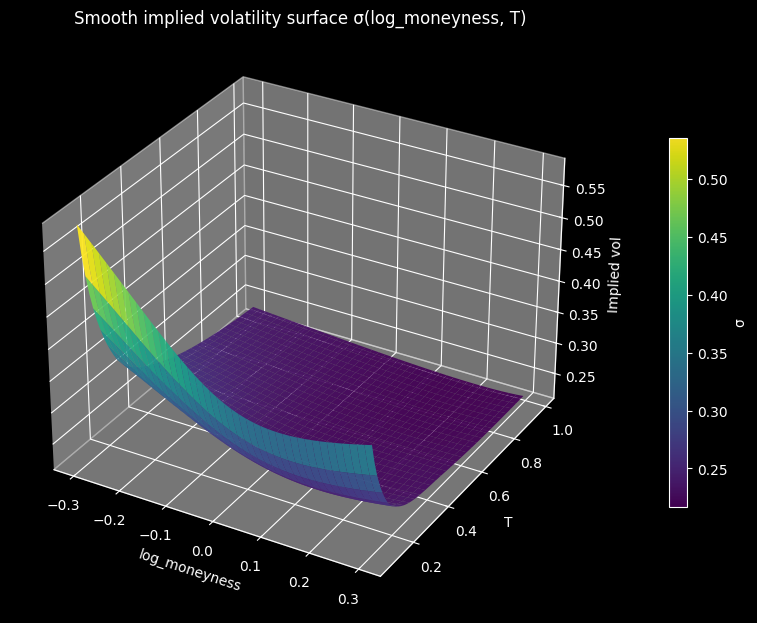

In [66]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(LM, TT, IV_surface, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)

ax.set_xlabel("log_moneyness")
ax.set_ylabel("T")
ax.set_zlabel("Implied vol")
ax.set_title("Smooth implied volatility surface σ(log_moneyness, T)")

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="σ")
plt.show()


In [67]:

fig = go.Figure(
    data=[
        go.Surface(
            x=LM,                 
            y=TT,                 
            z=IV_surface,         
            colorscale="Viridis",
            cmin=np.nanmin(IV_surface),
            cmax=np.nanmax(IV_surface),
            colorbar=dict(title="σ")
        )
    ]
)

fig.update_layout(
    template="plotly_dark",  
    title="Smooth implied volatility surface σ(log-moneyness, T)",
    width=900,
    height=700,
    scene=dict(
        xaxis_title="log-moneyness",
        yaxis_title="T",
        zaxis_title="Implied vol",
        xaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)"),
        yaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)"),
        zaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.12)")
    ),margin=dict(l=0, r=0, t=60, b=0))

fig.write_html("implied_vol_surface.html")

fig.show()


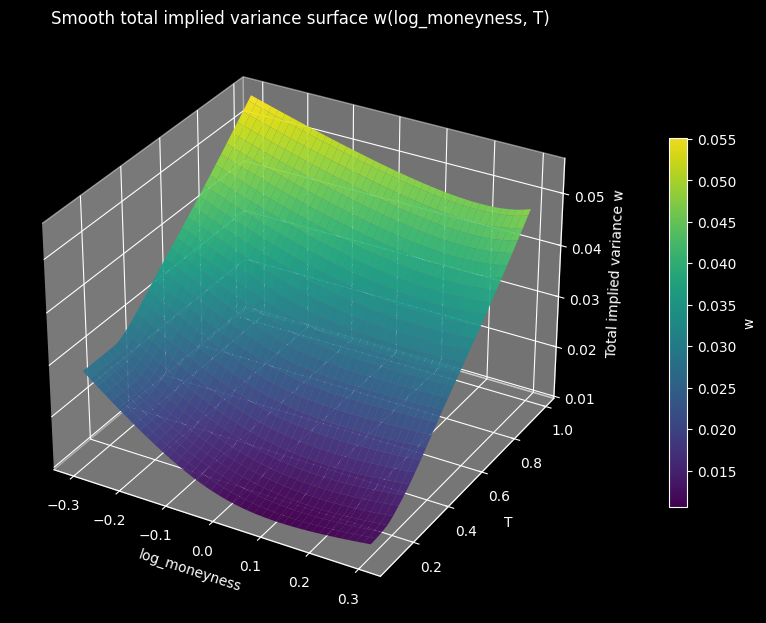

In [68]:
#### total implied variance surface

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(LM, TT, W_surface, cmap="viridis", linewidth=0, antialiased=True, alpha=0.95)

ax.set_xlabel("log_moneyness")
ax.set_ylabel("T")
ax.set_zlabel("Total implied variance w")
ax.set_title("Smooth total implied variance surface w(log_moneyness, T)")

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="w")
plt.show()


In [69]:
###### Smooth total implied variance surface
fig = go.Figure(
    data=[
        go.Surface(
            x=LM,          
            y=TT,          
            z=W_surface,   
            colorbar=dict(title="w"),
            opacity=0.95,
            
        )
    ]
)
fig.update_layout(
    template="plotly_dark",
    title="Smooth total implied variance surface w(log_moneyness, T)",
    scene=dict(
        xaxis_title="log_moneyness",
        yaxis_title="T",
        zaxis_title="Total implied variance w",
    ),
    width=950,
    height=750,
    margin=dict(l=0, r=0, b=0, t=50),
)

fig.show()

## Dupire

As a reminder, Dupire's formula is :

$$
\sigma_{\mathrm{loc}}^{2}(k,T)=\frac{\partial_T w}{1-
\frac{k}{w}\,\partial_k w+\frac{1}{4}\left(-\frac{1}{w}+
\frac{k^{2}}{w^{2}}\right)(\partial_k w)^2+
\frac{1}{2}\,\partial_{kk} w}
$$

$\sigma_{\mathrm{loc}}(k,T) \text{ : local volatility}$

$k = \log\!\left(\frac{K}{F_T}\right) \text{with: }$  

$F_T = S_0 e^{(r-q)T}$  

$\sigma_{\mathrm{imp}}(k,T) \text{ : implied volatility}$  

$w(k,T) = \sigma_{\mathrm{imp}}^2(k,T)\,T$ -> **(Theta)**

$\partial_T w \text{ : partial derivative of } w(k,T) \text{ with respect to }T \text{ at fixed }k$ -> **(dT_Theta)**

$\partial_k w \text{: partial derivative of } w(k,T) \text{ with respect to }k \text{ at fixed }T$ -> **(dLM_Theta)**

$\partial_{kk} w \text{: second partial derivative of } w(k,T) \text{ with respect to }k \text{ at fixed }T$ -> **(dLM2_Theta)**

In [81]:
Theta[2:,:]

array([[0.02803796, 0.02782401, 0.02761047, ..., 0.01200578, 0.01204416,
        0.01208286],
       [0.02803796, 0.02782401, 0.02761047, ..., 0.01207835, 0.01211632,
        0.01215464],
       [0.02803796, 0.02782401, 0.02761047, ..., 0.01217186, 0.01220935,
        0.01224723],
       ...,
       [0.05439486, 0.05431297, 0.05423123, ..., 0.04607047, 0.04616302,
        0.04626033],
       [0.05504483, 0.05496452, 0.05488433, ..., 0.04683132, 0.04692862,
        0.04703105],
       [0.05569798, 0.05561923, 0.05554059, ..., 0.04759606, 0.04769825,
        0.04780591]])

In [ ]:
T = T_grid_dense
Theta = W_surface.copy()

Theta = np.maximum(Theta, 1e-10) #avoiding Theta = 0 for num stability

# ---------- Derivatives ----------
# dTheta/dT : dérivée en T (central diff)
dT_Theta = np.empty_like(Theta)

# interior
dT_Theta[1:-1, :] = (Theta[2:, :] - Theta[:-2, :]) / (T[2:, None] - T[:-2, None])
# boundaries (one-sided)
dT_Theta[0, :] = (Theta[1, :] - Theta[0, :]) / (T[1] - T[0])
dT_Theta[-1, :] = (Theta[-1, :] - Theta[-2, :]) / (T[-1] - T[-2])

# dTheta/dLM and d2Theta/dLM2 : dérivées en log_moneyness
dLM_Theta = np.empty_like(Theta)
dLM2_Theta = np.empty_like(Theta)

# first derivative (central)
dLM_Theta[:, 1:-1] = (Theta[:, 2:] - Theta[:, :-2]) / (log_moneyness_grid[2:] - log_moneyness_grid[:-2])[None, :]
dLM_Theta[:, 0] = (Theta[:, 1] - Theta[:, 0]) / (log_moneyness_grid[1] - log_moneyness_grid[0])
dLM_Theta[:, -1] = (Theta[:, -1] - Theta[:, -2]) / (log_moneyness_grid[-1] - log_moneyness_grid[-2])

# second derivative (central)
h = log_moneyness_grid[1] - log_moneyness_grid[0]  # suppose grid quasi-uniforme; sinon on peut faire une version non-uniforme
dLM2_Theta[:, 1:-1] = (Theta[:, 2:] - 2 * Theta[:, 1:-1] + Theta[:, :-2]) / (h * h)
dLM2_Theta[:, 0] = dLM2_Theta[:, 1]
dLM2_Theta[:, -1] = dLM2_Theta[:, -2]

# ---------- Dupire (Gatheral form) ----------
KAPPA = log_moneyness_grid[None, :]  # broadcast to (nT, nLM)

term1 = 1.0 - (KAPPA / Theta) * dLM_Theta
term2 = 0.25 * (-0.25 - 1.0 / Theta + (KAPPA * KAPPA) / (Theta * Theta)) * (dLM_Theta * dLM_Theta)
term3 = 0.5 * dLM2_Theta

denom = term1 + term2 + term3

# local variance and local vol
local_var = dT_Theta / denom

# nettoyage numérique (évite NaN/neg)
local_var = np.where(np.isfinite(local_var), local_var, np.nan)
local_var = np.maximum(local_var, 0.0)

local_vol = np.sqrt(local_var)


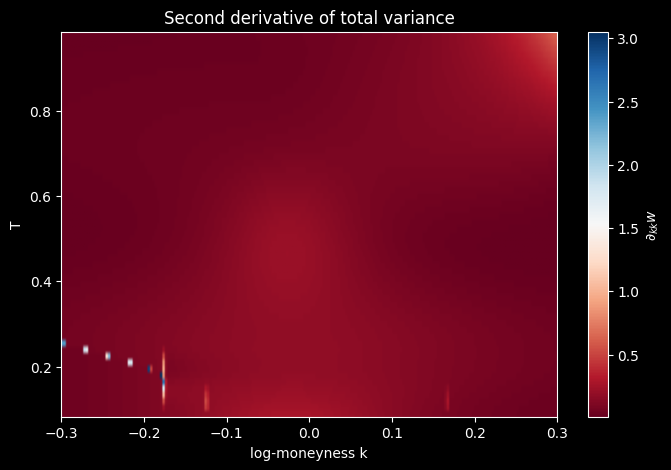

In [77]:


plt.figure(figsize=(8, 5))
plt.imshow(
    dLM2_Theta,
    aspect="auto",
    origin="lower",
    extent=[log_moneyness_grid.min(), log_moneyness_grid.max(), T.min(), T.max()],
    cmap="RdBu",
)
plt.colorbar(label=r"$\partial_{kk} w$")
plt.xlabel("log-moneyness k")
plt.ylabel("T")
plt.title("Second derivative of total variance")
plt.show()


In [78]:
%matplotlib inline

mask_T = T > 0.1
mask_LM = (log_moneyness_grid >= -0.25) & (log_moneyness_grid <= 0.25)

fig = go.Figure()
fig.add_surface(

    x=log_moneyness_grid[mask_LM],
    y=T[mask_T],
    z=local_vol[mask_T, :][:, mask_LM],
    colorscale="Viridis",
    colorbar=dict(title="σ_loc"),
)
fig.update_layout(
    template="plotly_dark",
    title="Dupire local volatility surface σ_loc(log_moneyness, T)",
    scene=dict(xaxis_title="log_moneyness", yaxis_title="T", zaxis_title="local vol"),
    width=900, height=700
)
fig.show()
